In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
import matplotlib.pyplot as plt

In [ ]:
x=np.linspace(1,5,150)
np.random.seed(42)
y=(5*(x**2)-6*x-10) +np.random.normal(0,10,len(x))

x_data = np.transpose([x])
y_data = np.transpose([y])

model=20
x_input=x_data

for i in range(model-1):
  power=i+2
  x_input=np.concatenate((x_input,x_data**power),axis=1)


scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_input)
#print(x_scaled)
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y_data,test_size=0.2,random_state=10)
#print(x_train)

In [ ]:
#linear regression using
lin_reg=linear_model.LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred=lin_reg.predict(x_scaled)

In [ ]:
def RMSE(y_pred,y_real):
  y=y_pred-y_real
  rms_y=np.sqrt(np.sum((y)**2)/len(y))
  return rms_y
y_predict_on_test=lin_reg.predict(x_test)
rmse=RMSE(y_predict_on_test,y_test)
print(f" Root Mean Squared Error (RMSE) on the test data : {rmse}")
#print(y_predict_on_test-y_test)


 Root Mean Squared Error (RMSE) on the test data : 8.489103699674105


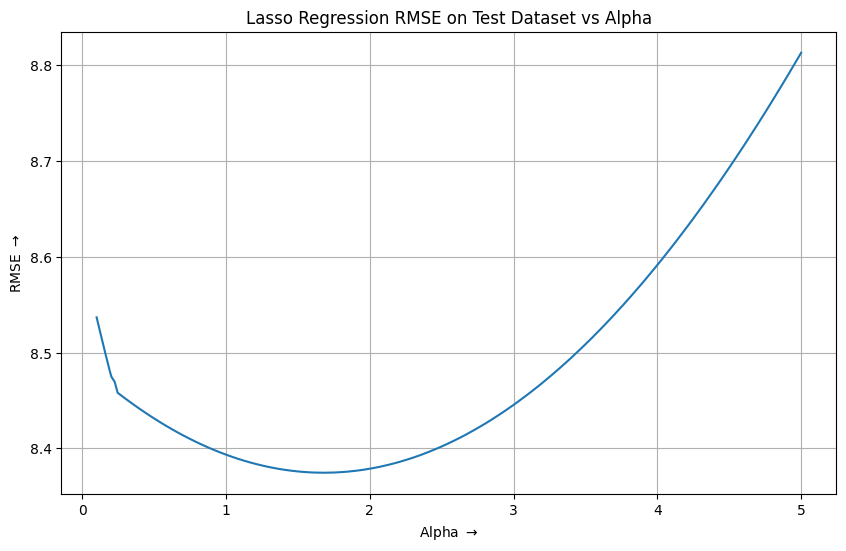

Value of alpha where RMSE on Test Dataset is minimum is 1.6882488248824883


In [ ]:
alpha_list=(np.linspace(0.1,5,10000))
RMSE_list=[]

rag_fitx=x_train
rag_fity=y_train

for i in alpha_list:
  lasso_rag=linear_model.Lasso(alpha=i,fit_intercept=True)
  lasso_rag.fit(rag_fitx,rag_fity)
  y_pred_lasso=lasso_rag.predict(x_test)
  y_pred_lasso=np.transpose([y_pred_lasso])

  rmse=RMSE(y_pred_lasso,y_test)
  RMSE_list.append(rmse)

plt.figure(figsize=(10,6))
plt.plot(alpha_list,RMSE_list)
plt.xlabel(r"Alpha $\rightarrow $")
plt.ylabel(r"RMSE $\rightarrow $")
plt.title("Lasso Regression RMSE on Test Dataset vs Alpha")
plt.grid()
plt.show()

minimum_index=RMSE_list.index(min(RMSE_list))
print(f"Value of alpha where RMSE on Test Dataset is minimum is {alpha_list[minimum_index]}")
alpha_min=alpha_list[minimum_index]

When alpha = 0.0001 ,RMSE =  516.2374256629872


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.311e+03, tolerance: 1.196e+01
  model = cd_fast.enet_coordinate_descent(


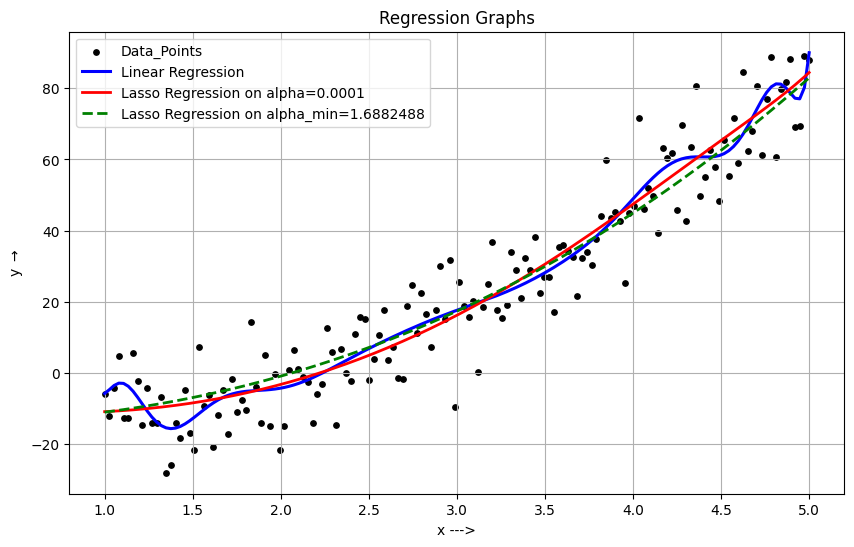

When alpha =1.6882488 ,RMSE =  502.602465439433


In [ ]:
# Comparison Graph
given_alpha=0.0001
lasso_rag=linear_model.Lasso(alpha=given_alpha,fit_intercept=True)
lasso_rag.fit(rag_fitx,rag_fity)
y_pred_lasso=lasso_rag.predict(x_scaled)

plt.figure(figsize=(10,6))

plt.scatter(x_data, y_data,  color='black',s=15)
plt.plot(x_data, y_pred, color='blue', linewidth=2.2)
plt.plot(x_data, y_pred_lasso, color='red', linewidth=2 ,linestyle="-")
print(f"When alpha = {given_alpha} ,RMSE = " ,RMSE(y_pred_lasso,y_data))

alpha2=round(alpha_min,7)
lasso_rag=linear_model.Lasso(alpha=alpha2,fit_intercept=True)
lasso_rag.fit(rag_fitx,rag_fity)
y_pred_lasso=lasso_rag.predict(x_scaled)
plt.plot(x_data, y_pred_lasso, color='g', linewidth=2 ,linestyle="--")

plt.xlabel("x --->")
plt.ylabel(r"y $\rightarrow$")
plt.title("Regression Graphs")
plt.legend(["Data_Points","Linear Regression","Lasso Regression on alpha=0.0001",f"Lasso Regression on alpha_min={alpha2}"])

plt.grid()
plt.show()
"""print(y_pred_lasso,y_data)"""
print(f"When alpha ={alpha2} ,RMSE = " ,RMSE(y_pred_lasso,y_data))

In [ ]:
y1=np.array([1,2,3])
y2=np.array([5,3,4])
print(y1-y2)

[-4 -1 -1]
